In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 103M/103M [00:00<00:00, 122MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset):
['Car', 'Bike']


In [ ]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset/Car/Car (936).jpeg
Example image label: Car


In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally set memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found. Training will proceed on CPU (which may be slow).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

# Create DataFrames for the generators
train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

validation_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

# Build DenseNet Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers for initial training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 3196 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/10
 45/100 ━━━━━━━━━━━━━━━━━━━━ 24s 450ms/step - accuracy: 0.8810 - loss: 0.2591

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 105s 758ms/step - accuracy: 0.9634 - loss: 0.0971 - val_accuracy: 0.9925 - val_loss: 0.0144
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 473ms/step - accuracy: 0.9831 - loss: 0.0452 - val_accuracy: 0.9950 - val_loss: 0.0131
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.9850 - loss: 0.0472 - val_accuracy: 0.9975 - val_loss: 0.0075
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 460ms/step - accuracy: 0.9859 - loss: 0.0408 - val_accuracy: 0.9987 - val_loss: 0.0051
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 474ms/step - accuracy: 0.9850 - loss: 0.0387 - val_accuracy: 0.9962 - val_loss: 0.0099
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 463ms/step - accuracy: 0.9856 - loss: 0.0391 - val_accuracy: 0.9962 - val_loss: 0.0094
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 463ms/step - accuracy: 0.9900 - loss: 0.0300 - val_accuracy: 0.9987 - val_loss: 0.0062
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 470ms/step - accuracy: 0.9903 - loss: 0.0261 - va

In [ ]:
# Summarize training results
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9987 - loss: 0.0054
Final Validation Loss: 0.0054
Final Validation Accuracy: 0.9987


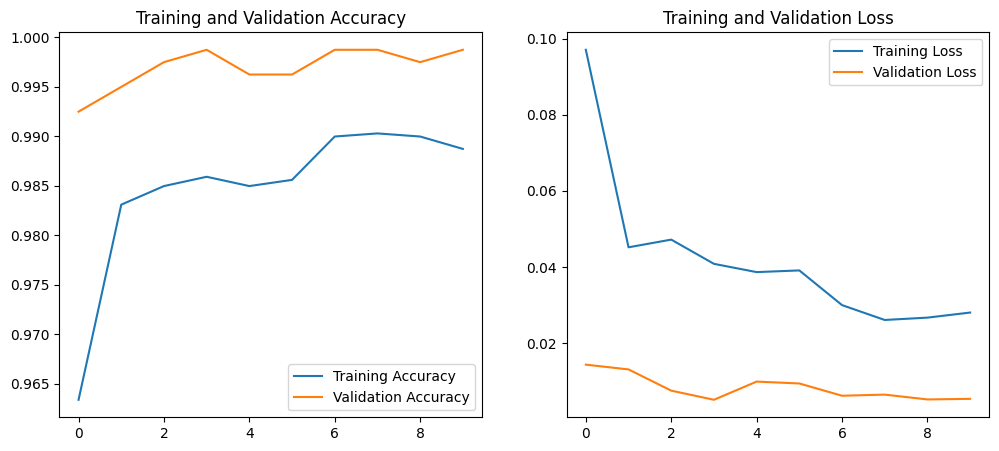

In [ ]:
import matplotlib.pyplot as plt

# Visualize training metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()